# Project 1 Master Notebook

This notebook shows how to load the data, run backtests, compare strategies, and plot the results.

In [102]:
%load_ext autoreload
%autoreload 2
import pandas as pd

from utils import read_price_data, make_long_form_dataframe, make_close_price_matrix
from backtester import Backtester, compare_backtests
from stock_strategies import *
from portfolio_strategies import *
from plot_utils import *
from simulation import *
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [94]:
# Update this path if your CSV is stored somewhere else.
CSV_PATH = 'data/nasdaq100_daily_5y.csv'

raw_df = read_price_data(CSV_PATH)
long_df = make_long_form_dataframe(raw_df)
price_matrix = make_close_price_matrix(long_df)

print(long_df.head())
print('Shape:', long_df.shape)
print('Number of stocks:', price_matrix.shape[1])
print('Date range:', price_matrix.index.min(), 'to', price_matrix.index.max())

backtester = Backtester(price_matrix, initial_cash=1.0, transaction_cost=0.0005)

  ticker       date     open      high     low   close      volume
0   AAPL 2021-04-13  132.440  134.6600  131.93  134.43  90761995.0
1   ABNB 2021-04-13  175.265  178.6100  172.14  177.95   3573584.0
2   ADBE 2021-04-13  506.850  517.2645  506.78  514.86   2195707.0
3    ADI 2021-04-13  160.550  160.9500  157.36  159.16   1704620.0
4    ADP 2021-04-13  189.860  192.2200  189.55  191.92   1978958.0
Shape: (124330, 7)
Number of stocks: 101
Date range: 2021-04-13 00:00:00 to 2026-04-10 00:00:00


## Single-stock Backtesting

Pick one stock and compare several classic strategies.

In [88]:
ticker = 'NVDA'

single_stock_results = {
    'Momentum': backtester.run_strategy(single_stock_momentum(ticker, lookback=20), 'Momentum'),
    'Mean Reversion': backtester.run_strategy(single_stock_mean_reversion(ticker, lookback=5, threshold=-0.03), 'Mean Reversion'),
    'SMA Crossover': backtester.run_strategy(single_stock_sma_crossover(ticker, short_window=20, long_window=50), 'SMA Crossover'),
    'Breakout': backtester.run_strategy(single_stock_breakout(ticker, lookback=20), 'Breakout'),
    'Low-Vol Momentum': backtester.run_strategy(single_stock_low_vol_momentum(ticker, lookback=20, vol_window=20, max_vol=0.025), 'Low-Vol Momentum'),
}

single_stock_metrics = compare_backtests(single_stock_results)
single_stock_metrics


,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,win_rate
Low-Vol Momentum,0.268987,0.055827,0.114693,0.486755,0.221096,-0.161034,0.035060
Momentum,0.250299,0.117124,0.362943,0.322706,0.371119,-0.465688,0.294024
Breakout,-0.042375,0.013034,0.207530,0.062807,0.039731,-0.481422,0.090040
SMA Crossover,-0.288361,0.005928,0.385016,0.015398,0.018339,-0.690306,0.287649
Mean Reversion,-0.412491,-0.058791,0.303841,-0.193494,-0.185804,-0.713618,0.159363


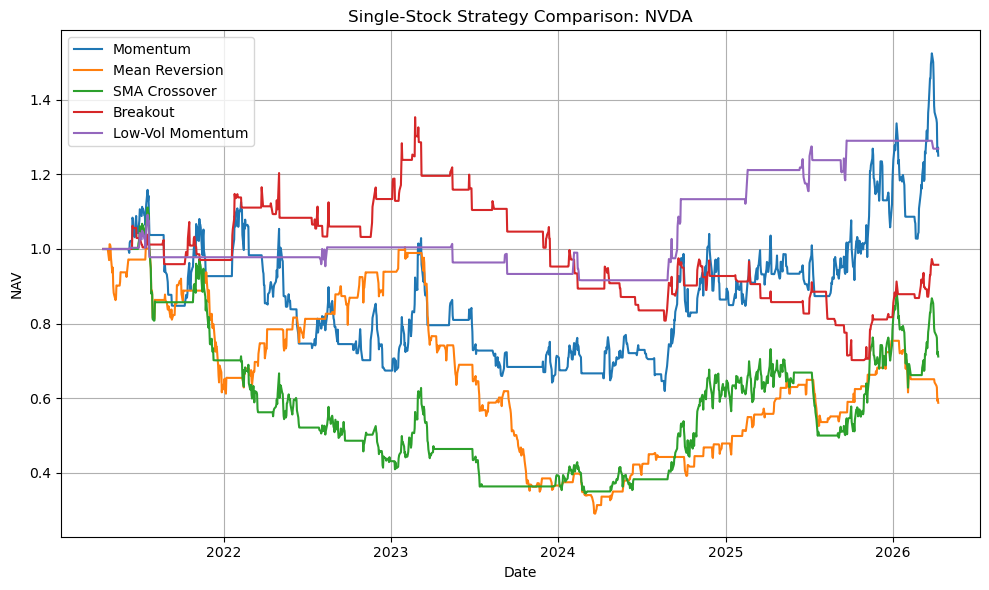

In [123]:
plot_nav_curves(single_stock_results, title=f'Single-Stock Strategy Comparison: {ticker}')


## Portfolio Real Data Testing

Below are the two benchmark strategies from the project description and several extension strategies.

In [95]:
portfolio_results = {
    'SMA Cross (B1)': backtester.run_strategy(benchmark_sma_cross(short_window=20, long_window=50), 
                                                       'SMA Cross (B1)'),
    'TopK Momentum (B2)': backtester.run_strategy(benchmark_topk_momentum(lookback=30, top_k=10), 
                                                           'TopK Momentum (B2)'),
    'Trend TopK Momentum (A1)': backtester.run_strategy(trend_filtered_topk_momentum(lookback=20, top_k=10, vol_window=20, 
                                                           stock_ma_window=50, market_ma_window=200), 
                                                           'Trend TopK Momentum (A1)'),
    'TopK Momentum with Pullback (A2)': backtester.run_strategy(momentum_with_pullback(lookback=90, short_lookback=5, top_k=10, vol_window=20, 
                                                     stock_ma_window=100), 
                                                     'TopK Momentum with Pullback (A2)')
}

portfolio_metrics = compare_backtests(portfolio_results)
portfolio_metrics


/Users/raidriard/Desktop/UCBS26/INDENG231/Project/project1/portfolio_strategies.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inv_vol = inv_vol.fillna(0.0)
/Users/raidriard/Desktop/UCBS26/INDENG231/Project/project1/portfolio_strategies.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inv_vol = inv_vol.fillna(0.0)


,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,win_rate
TopK Momentum with Pullback (A2),2.849919,0.359707,0.270596,1.329310,1.938837,-0.410498,0.508367
Trend TopK Momentum (A1),1.233253,0.197153,0.193148,1.020738,1.220039,-0.224267,0.318725
TopK Momentum (B2),1.761729,0.273827,0.275744,0.993048,1.451182,-0.454800,0.521116
SMA Cross (B1),0.634060,0.123693,0.189660,0.652183,0.907281,-0.385317,0.516335


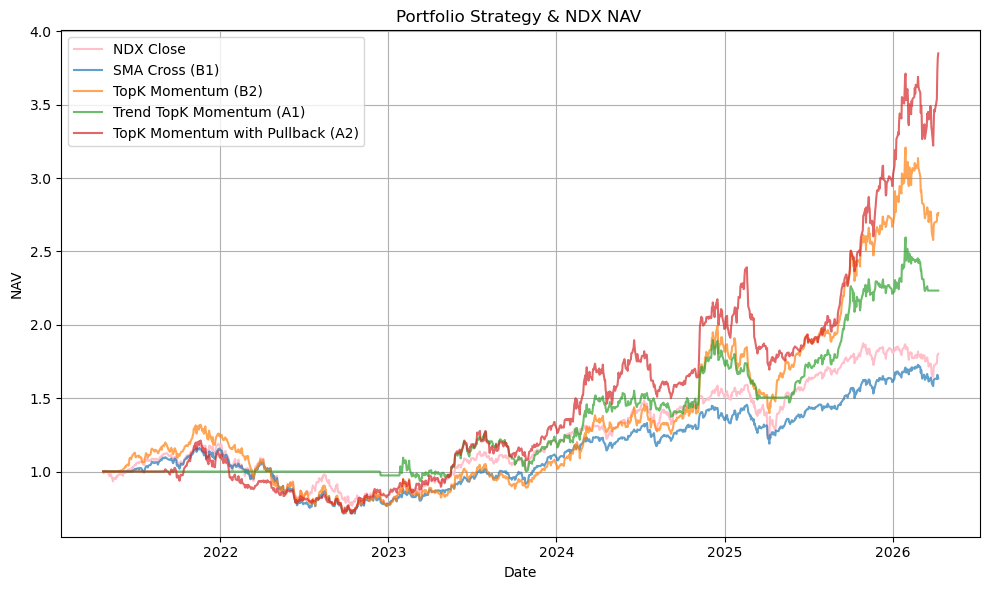

In [112]:
plot_nav_and_NDX(portfolio_results,ndx_path="data/NDX_daily_5y.csv", 
                 title="Portfolio Strategy & NDX NAV ")

### Visualizing the Trend Topk Momentum (A1) Strategy

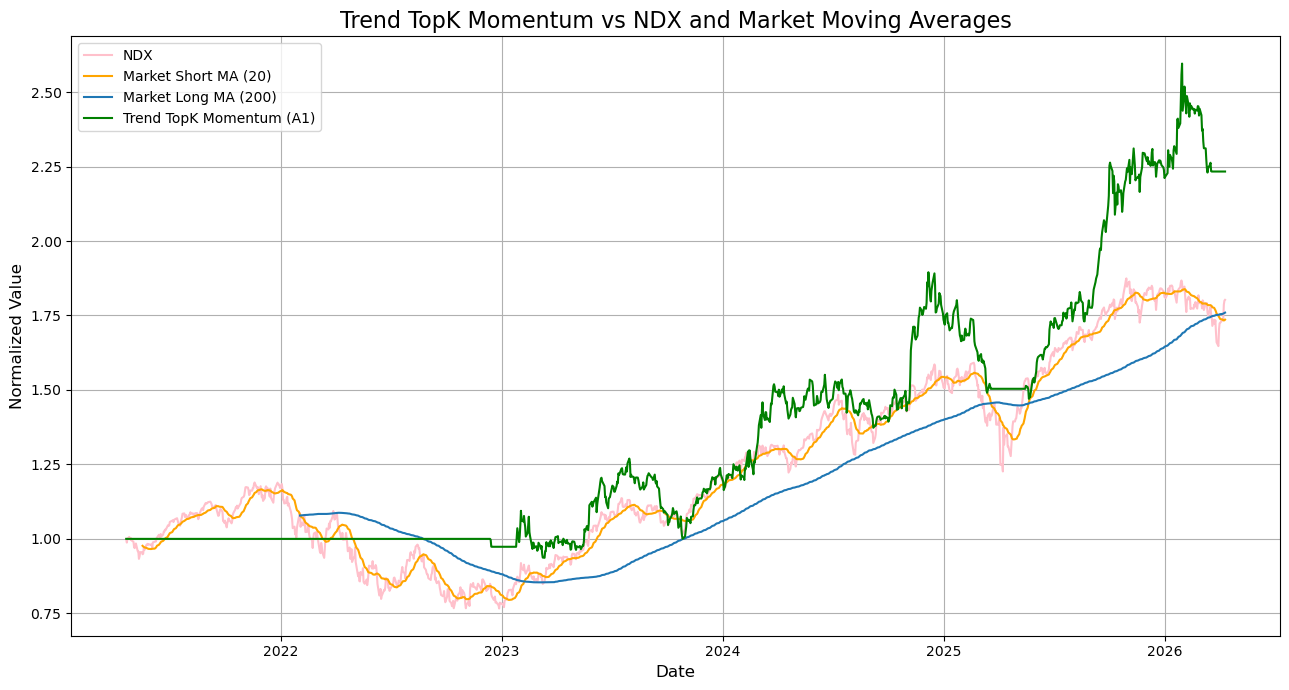

In [115]:

plot_strategy_with_NDX_and_ma(results=portfolio_results,strategy_name="Trend TopK Momentum (A1)", 
                              ndx_path="data/NDX_daily_5y.csv",
                              ma_short=20,ma_long=200)



### Examine the weights for Topk stock selections

In [ ]:
# example_weights = portfolio_results['TopK Momentum with Pullback'].weights
# largest_average_weights = list(example_weights.mean().nlargest(5).index)
# print('Five tickers with the highest average portfolio weight:', largest_average_weights)
# plot_weights_over_time(example_weights, tickers=largest_average_weights, title='TopK Momentum + Inverse Vol: Largest Average Weights')


In [41]:
# single_stock_metrics.to_csv('eval/single_stock_metrics.csv')
# portfolio_metrics.to_csv('eval/portfolio_metrics.csv')
# print('Saved metric tables to CSV.')


Saved metric tables to CSV.


## Portfolio Simulated Data Backtesting

In [120]:
# Choose a strategy to test under repeated simulations.

simulation_strategy_name = 'TopK Momentum (B2)'
simulation_strategy_func = benchmark_topk_momentum(lookback=30, top_k=10)

                                                     
                                                           
N_SIMULATIONS = 100
SIMULATION_MODEL = 'factor'   # choose 'independent' or 'factor'
SIMULATION_SEED = 2049

if SIMULATION_MODEL == 'independent':
    simulation_summary = simulate_independent_normal_prices(price_matrix, n_simulations=N_SIMULATIONS, seed=SIMULATION_SEED)
else:
    simulation_summary = simulate_factor_normal_prices(price_matrix, n_simulations=N_SIMULATIONS, seed=SIMULATION_SEED)

simulation_result = backtester.run_strategy_on_simulations(
    simulation_strategy_func,
    simulation_summary.simulated_paths,
    strategy_name=simulation_strategy_name,
    simulation_model=simulation_summary.model_name,
)

simulation_result.metric_summary


,mean,variance,std
cumulative_return,1.667857,4.447860,2.108995
annualized_return,0.213645,0.034685,0.186240
annualized_volatility,0.284247,0.000099,0.009953
sharpe_ratio,0.735080,0.400480,0.632835
sortino_ratio,1.186668,1.050645,1.025010
max_drawdown,-0.411742,0.012593,0.112216
win_rate,0.503761,0.000266,0.016318


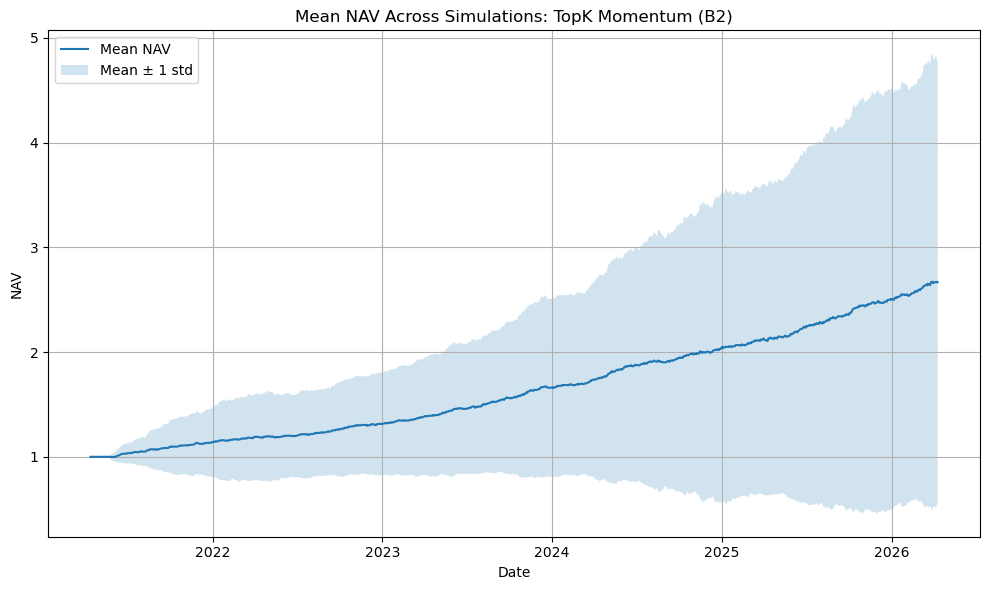

Saved simulation metric tables to CSV.


In [122]:
plot_mean_nav_with_band(
    simulation_result.mean_nav,
    simulation_result.nav_paths,
    title=f"Mean NAV Across Simulations: {simulation_strategy_name}",
)

# Save the aggregated simulated results if needed.
if SIMULATION_MODEL == 'independent':
    mode = 'ind'
else:
    mode = 'fac'
simulation_result.metric_table.to_csv(f'sim/{simulation_strategy_name}_{mode}_table.csv')
simulation_result.metric_summary.to_csv(f'sim/{simulation_strategy_name}_{mode}_summary.csv')
print('Saved simulation metric tables to CSV.')
